Importing all the necessary libraries

In [ ]:
import numpy as np
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import pandas as pd

Load data function to sort words with their corresponding tags using extract_features

In [26]:
def load_data(file_path):
    '''
    Loads data from a tab-separated file where each line contains a word and its tag.
    Empty lines in the file indicate sentence boundaries.

    Args:
        file_path: Path to the input file

    Returns:
        A list of sentences, where each sentence is a list of (word, tag) tuples
    '''
    sentences = []  # List to store all sentences
    sentence = []   # Temporary list to build current sentence

    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            line = line.strip()
            if line:  # If line is not empty
                word, tag = line.split('\t')  # Split line by tab to get word and tag
                sentence.append((word, tag))  # Add the word-tag pair to current sentence
            else:  # Empty line indicates end of sentence
                if sentence:  # Only add non-empty sentences
                    sentences.append(sentence)  # Add completed sentence to sentences list
                    sentence = []  # Reset for next sentence
        # Handle case where file doesn't end with an empty line
        if sentence:  # Add the last sentence if it exists
            sentences.append(sentence)

    return sentences

def extract_features(sentences):
    '''
    Extracts words and tags from the sentences data structure.
    Separates the words and tags into their own lists while maintaining sentence boundaries.

    Args:
        sentences: List of sentences, where each sentence is a list of (word, tag) tuples

    Returns:
        words: List of sentences, where each sentence is a list of words
        tags: List of sentences, where each sentence is a list of tags
    '''
    words = []  # List to store word sequences for each sentence
    tags = []   # List to store tag sequences for each sentence

    for sentence in sentences:
        words.append([word for word, _ in sentence])  # Extract just the words from the sentence
        tags.append([tag for _, tag in sentence])     # Extract just the tags from the sentence

    return words, tags



Declaration of HMM Class with functions train, get_word_features, viterbi, predict

In [27]:
class HMM:
    def __init__(self, n_gram=2, use_context=False, alpha=0.4):
        self.n_gram = n_gram  # 2 for bigram, 3 for trigram
        self.use_context = use_context
        self.alpha = alpha  # Smoothing parameter
        self.states = set()
        self.vocab = set()
        self.start_prob = defaultdict(float)
        self.trans_prob = defaultdict(lambda: defaultdict(float))
        self.emit_prob = defaultdict(lambda: defaultdict(float))

        # Special tokens for unknown words
        self.unk_tokens = ["<UNK>", "<UNK_UPPER>", "<UNK_DIGIT>", "<UNK_PUNCT>"]
        for token in self.unk_tokens:
            self.vocab.add(token)

        if self.n_gram == 3:  # For trigram
            self.trans_prob_trigram = defaultdict(lambda: defaultdict(lambda: defaultdict(float)))

    def train(self, train_sentences):
        # Step 1: Find states and vocabulary
        for sentence in train_sentences:
            for word, tag in sentence:
                self.states.add(tag)
                self.vocab.add(word)

        # Step 2: Calculate start probabilities
        tag_counts = Counter()
        start_tag_counts = Counter()

        for sentence in train_sentences:
            if sentence:
                _, first_tag = sentence[0]
                start_tag_counts[first_tag] += 1

            for _, tag in sentence:
                tag_counts[tag] += 1

        total_sentences = len(train_sentences)
        # Apply smoothing to start probabilities
        for tag in self.states:
            self.start_prob[tag] = (start_tag_counts[tag] + self.alpha) / (total_sentences + self.alpha * len(self.states))

        # Step 3: Calculate transition probabilities
        tag_bigram_counts = defaultdict(Counter)
        tag_trigram_counts = defaultdict(lambda: defaultdict(Counter))

        for sentence in train_sentences:
            tags = [tag for _, tag in sentence]

            # Bigram transitions
            for i in range(len(tags) - 1):
                tag_bigram_counts[tags[i]][tags[i+1]] += 1

            # Trigram transitions (if using trigram model)
            if self.n_gram == 3:
                for i in range(len(tags) - 2):
                    tag_trigram_counts[tags[i]][tags[i+1]][tags[i+2]] += 1

        # Calculate bigram transition probabilities with smoothing
        for prev_tag in self.states:
            total = sum(tag_bigram_counts[prev_tag].values()) + self.alpha * len(self.states)
            for curr_tag in self.states:
                self.trans_prob[prev_tag][curr_tag] = (tag_bigram_counts[prev_tag][curr_tag] + self.alpha) / total

        # Calculate trigram transition probabilities with smoothing (if using trigram model)
        if self.n_gram == 3:
            for t1 in self.states:
                for t2 in self.states:
                    total = sum(tag_trigram_counts[t1][t2].values()) + self.alpha * len(self.states)
                    for t3 in self.states:
                        self.trans_prob_trigram[t1][t2][t3] = (tag_trigram_counts[t1][t2][t3] + self.alpha) / total

        # Step 4: Calculate emission probabilities
        tag_word_counts = defaultdict(Counter)
        context_tag_word_counts = defaultdict(lambda: defaultdict(Counter))

        for sentence in train_sentences:
            for i, (word, tag) in enumerate(sentence):
                tag_word_counts[tag][word] += 1

                # If using context, consider the previous tag
                if self.use_context and i > 0:
                    prev_tag = sentence[i-1][1]
                    context_tag_word_counts[prev_tag][tag][word] += 1

        # Calculate emission probabilities with smoothing
        if not self.use_context:
            for tag in self.states:
                total = sum(tag_word_counts[tag].values()) + self.alpha * len(self.vocab)
                for word in self.vocab:
                    self.emit_prob[tag][word] = (tag_word_counts[tag].get(word, 0) + self.alpha) / total
        else:
            # With context (previous tag)
            for prev_tag in self.states:
                for curr_tag in self.states:
                    total = sum(context_tag_word_counts[prev_tag][curr_tag].values()) + self.alpha * len(self.vocab)
                    for word in self.vocab:
                        self.emit_prob[(prev_tag, curr_tag)][word] = (context_tag_word_counts[prev_tag][curr_tag].get(word, 0) + self.alpha) / total

            # Also calculate regular emission probabilities for the first word in a sentence
            for tag in self.states:
                total = sum(tag_word_counts[tag].values()) + self.alpha * len(self.vocab)
                for word in self.vocab:
                    self.emit_prob[tag][word] = (tag_word_counts[tag].get(word, 0) + self.alpha) / total

    def get_word_features(self, word):
        """Extract features from a word to handle unknown words better"""
        if word[0].isupper():
            return "<UNK_UPPER>"
        elif word.isdigit():
            return "<UNK_DIGIT>"
        elif not word.isalnum():
            return "<UNK_PUNCT>"
        else:
            return "<UNK>"

    def viterbi(self, sentence):
        # Handle unknown words
        processed_sentence = []
        for word in sentence:
            if word in self.vocab:
                processed_sentence.append(word)
            else:
                processed_sentence.append(self.get_word_features(word))

        T = len(processed_sentence)
        states = list(self.states)

        # Initialize viterbi and backpointer matrices
        viterbi_matrix = np.zeros((len(states), T))
        backpointer = np.zeros((len(states), T), dtype=int)

        # Special case for bigram model
        if self.n_gram == 2:
            # Initialization step
            for s in range(len(states)):
                start_prob = max(self.start_prob[states[s]], 1e-10)
                emit_prob = max(self.emit_prob[states[s]][processed_sentence[0]], 1e-10)
                viterbi_matrix[s, 0] = np.log(start_prob) + np.log(emit_prob)

            # Recursion step
            for t in range(1, T):
                for s in range(len(states)):
                    curr_tag = states[s]

                    if not self.use_context:
                        emission_prob = max(self.emit_prob[curr_tag][processed_sentence[t]], 1e-10)
                    else:
                        # Find the best previous tag
                        best_prev_tag_idx = np.argmax([viterbi_matrix[s_prev, t-1] +
                                                     np.log(max(self.trans_prob[states[s_prev]][curr_tag], 1e-10))
                                                     for s_prev in range(len(states))])
                        best_prev_tag = states[best_prev_tag_idx]

                        # Use context-based emission probability
                        emission_prob = max(self.emit_prob.get((best_prev_tag, curr_tag), {}).get(processed_sentence[t], 1e-10), 1e-10)

                    max_prob = -float('inf')
                    max_idx = 0

                    for s_prev in range(len(states)):
                        prev_tag = states[s_prev]
                        transition_prob = max(self.trans_prob[prev_tag][curr_tag], 1e-10)

                        prob = viterbi_matrix[s_prev, t-1] + np.log(transition_prob)

                        if prob > max_prob:
                            max_prob = prob
                            max_idx = s_prev

                    viterbi_matrix[s, t] = max_prob + np.log(emission_prob)
                    backpointer[s, t] = max_idx

        # Special case for trigram model
        elif self.n_gram == 3:
            # For trigram model, we need to keep track of the previous two states
            # This is a simplified implementation and might need adjustments

            # Initialize with bigram for the first two positions
            for s in range(len(states)):
                start_prob = max(self.start_prob[states[s]], 1e-10)
                emit_prob = max(self.emit_prob[states[s]][processed_sentence[0]], 1e-10)
                viterbi_matrix[s, 0] = np.log(start_prob) + np.log(emit_prob)

            if T > 1:
                for s in range(len(states)):
                    curr_tag = states[s]
                    max_prob = -float('inf')
                    max_idx = 0

                    for s_prev in range(len(states)):
                        prev_tag = states[s_prev]
                        transition_prob = max(self.trans_prob[prev_tag][curr_tag], 1e-10)

                        if not self.use_context:
                            emission_prob = max(self.emit_prob[curr_tag][processed_sentence[1]], 1e-10)
                        else:
                            emission_prob = max(self.emit_prob.get((prev_tag, curr_tag), {}).get(processed_sentence[1], 1e-10), 1e-10)

                        prob = viterbi_matrix[s_prev, 0] + np.log(transition_prob) + np.log(emission_prob)

                        if prob > max_prob:
                            max_prob = prob
                            max_idx = s_prev

                    viterbi_matrix[s, 1] = max_prob
                    backpointer[s, 1] = max_idx

            # Use trigram transitions for the rest
            for t in range(2, T):
                for s in range(len(states)):
                    curr_tag = states[s]
                    max_prob = -float('inf')
                    max_idx = 0

                    for s_prev in range(len(states)):
                        prev_tag = states[s_prev]
                        prev_prev_idx = backpointer[s_prev, t-1]
                        prev_prev_tag = states[prev_prev_idx]

                        transition_prob = max(self.trans_prob_trigram[prev_prev_tag][prev_tag][curr_tag], 1e-10)

                        if not self.use_context:
                            emission_prob = max(self.emit_prob[curr_tag][processed_sentence[t]], 1e-10)
                        else:
                            emission_prob = max(self.emit_prob.get((prev_tag, curr_tag), {}).get(processed_sentence[t], 1e-10), 1e-10)

                        prob = viterbi_matrix[s_prev, t-1] + np.log(transition_prob) + np.log(emission_prob)

                        if prob > max_prob:
                            max_prob = prob
                            max_idx = s_prev

                    viterbi_matrix[s, t] = max_prob
                    backpointer[s, t] = max_idx

        # Termination step
        best_path_pointer = np.argmax(viterbi_matrix[:, T-1])

        # Backtracking
        best_path = [0] * T
        best_path[T-1] = best_path_pointer

        for t in range(T-1, 0, -1):
            best_path[t-1] = backpointer[best_path[t], t]

        return [states[i] for i in best_path]

    def predict(self, sentences):
        predictions = []
        for sentence in sentences:
            tags = self.viterbi(sentence)
            predictions.append(tags)
        return predictions


Save predictions and evaluate function to test data and save predictions made over validation set

In [28]:
def evaluate(true_tags, pred_tags):
    """
    Calculate accuracy, precision, recall, and F1 score.

    Args:
        true_tags: List of lists of true tags
        pred_tags: List of lists of predicted tags

    Returns:
        Dictionary with evaluation metrics
    """
    # Flatten the lists
    true_flat = [tag for sent in true_tags for tag in sent]
    pred_flat = [tag for sent in pred_tags for tag in sent]

    # Calculate accuracy
    correct = sum(t == p for t, p in zip(true_flat, pred_flat))
    total = len(true_flat)
    accuracy = correct / total if total > 0 else 0

    # Calculate precision, recall, and F1 for each tag
    tag_metrics = {}
    all_tags = set(true_flat) | set(pred_flat)

    for tag in all_tags:
        true_positives = sum(1 for t, p in zip(true_flat, pred_flat) if t == tag and p == tag)
        false_positives = sum(1 for t, p in zip(true_flat, pred_flat) if t != tag and p == tag)
        false_negatives = sum(1 for t, p in zip(true_flat, pred_flat) if t == tag and p != tag)

        precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
        recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

        tag_metrics[tag] = {
            'precision': precision,
            'recall': recall,
            'f1': f1
        }

    # Calculate macro-averaged metrics
    macro_precision = sum(m['precision'] for m in tag_metrics.values()) / len(tag_metrics) if tag_metrics else 0
    macro_recall = sum(m['recall'] for m in tag_metrics.values()) / len(tag_metrics) if tag_metrics else 0
    macro_f1 = 2 * macro_precision * macro_recall / (macro_precision + macro_recall) if (macro_precision + macro_recall) > 0 else 0

    return {
        'accuracy': accuracy,
        'macro_precision': macro_precision,
        'macro_recall': macro_recall,
        'macro_f1': macro_f1,
        'tag_metrics': tag_metrics
    }

def save_predictions(sentences, predictions, output_file):
    """
    Save predictions to a file.

    Args:
        sentences: List of lists of words
        predictions: List of lists of predicted tags
        output_file: Path to output file
    """
    with open(output_file, 'w', encoding='utf-8') as f:
        for sentence, tags in zip(sentences, predictions):
            for word, tag in zip(sentence, tags):
                f.write(f"{word}\t{tag}\n")
            f.write("\n")


Declaration find_optimal_alpha function which is used to find optimal values of alpha (laplace smoothening parameter) so that most accurate results achieved

In [29]:
def find_optimal_alpha(train_data, dev_data, alpha_values=None, n_gram=2, use_context=False):
    """
    Find the optimal alpha value for smoothing in HMM by testing different values.

    Parameters:
    -----------
    train_data : list
        List of training sentences, where each sentence is a list of (word, tag) tuples.
    dev_data : list
        List of development sentences for evaluation, same format as train_data.
    alpha_values : list, optional
        List of alpha values to test. Default is [0.001, 0.01, 0.05, 0.1, 0.125, 0.2, 0.5, 1.0].
    n_gram : int, optional
        Order of the n-gram model (2 for bigram, 3 for trigram). Default is 2.
    use_context : bool, optional
        Whether to use context for emission probabilities. Default is False.

    Returns:
    --------
    tuple
        (optimal_alpha, best_metrics, results_dict)
        - optimal_alpha: The alpha value that gave the highest accuracy
        - best_metrics: Dictionary with best metrics (accuracy, precision, recall, f1)
        - results_dict: Dictionary mapping alpha values to their metrics
    """
    if alpha_values is None:
        alpha_values = [0.001, 0.01, 0.05, 0.1, 0.125, 0.2, 0.5, 1.0]

    # Extract dev sentences and gold tags
    dev_sentences = [[word for word, _ in sentence] for sentence in dev_data]
    gold_tags = [[tag for _, tag in sentence] for sentence in dev_data]

    results = {}
    best_accuracy = 0
    optimal_alpha = None
    best_metrics = {}

    print(f"Testing {len(alpha_values)} alpha values: {alpha_values}")

    for alpha in alpha_values:
        print(f"Training HMM with alpha={alpha}...")

        # Initialize and train HMM with current alpha
        hmm = HMM(n_gram=n_gram, use_context=use_context, alpha=alpha)
        hmm.train(train_data)

        # Predict tags on dev data
        predicted_tags = hmm.predict(dev_sentences)

        # Calculate metrics
        correct = 0
        total = 0

        # For precision, recall, F1 calculation
        tag_metrics = defaultdict(lambda: {'tp': 0, 'fp': 0, 'fn': 0})

        for pred, gold in zip(predicted_tags, gold_tags):
            for p, g in zip(pred, gold):
                if p == g:
                    correct += 1
                    tag_metrics[p]['tp'] += 1
                else:
                    tag_metrics[p]['fp'] += 1
                    tag_metrics[g]['fn'] += 1
                total += 1

        # Calculate overall metrics
        accuracy = correct / total if total > 0 else 0

        # Calculate macro-averaged precision, recall, and F1
        precision_sum = 0
        recall_sum = 0
        f1_sum = 0
        tag_count = 0

        for tag, counts in tag_metrics.items():
            tag_precision = counts['tp'] / (counts['tp'] + counts['fp']) if (counts['tp'] + counts['fp']) > 0 else 0
            tag_recall = counts['tp'] / (counts['tp'] + counts['fn']) if (counts['tp'] + counts['fn']) > 0 else 0
            tag_f1 = 2 * tag_precision * tag_recall / (tag_precision + tag_recall) if (tag_precision + tag_recall) > 0 else 0

            precision_sum += tag_precision
            recall_sum += tag_recall
            f1_sum += tag_f1
            tag_count += 1

        macro_precision = precision_sum / tag_count if tag_count > 0 else 0
        macro_recall = recall_sum / tag_count if tag_count > 0 else 0
        macro_f1 = f1_sum / tag_count if tag_count > 0 else 0

        # Store metrics
        metrics = {
            'accuracy': accuracy,
            'precision': macro_precision,
            'recall': macro_recall,
            'f1': macro_f1
        }

        results[alpha] = metrics

        print(f"Alpha={alpha}, Accuracy={accuracy:.4f}, Precision={macro_precision:.4f}, Recall={macro_recall:.4f}, F1={macro_f1:.4f}")

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            optimal_alpha = alpha
            best_metrics = metrics

    print(f"\nOptimal alpha value: {optimal_alpha}")
    print(f"Best metrics: Accuracy={best_metrics['accuracy']:.4f}, Precision={best_metrics['precision']:.4f}, Recall={best_metrics['recall']:.4f}, F1={best_metrics['f1']:.4f}")

    return optimal_alpha, best_metrics, results


Testing find_optimal_alpha function over range of values of alpha to find the most the optimal value, and plot relevant curves to see the trends

Testing 13 alpha values: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.1, 1.2, 1.3]
Training HMM with alpha=0.1...
Alpha=0.1, Accuracy=0.7134, Precision=0.2397, Recall=0.1700, F1=0.1465
Training HMM with alpha=0.2...
Alpha=0.2, Accuracy=0.7463, Precision=0.2547, Recall=0.1504, F1=0.1364
Training HMM with alpha=0.3...
Alpha=0.3, Accuracy=0.7851, Precision=0.2743, Recall=0.1188, F1=0.1198
Training HMM with alpha=0.4...
Alpha=0.4, Accuracy=0.8039, Precision=0.4124, Recall=0.0985, F1=0.0994
Training HMM with alpha=0.5...
Alpha=0.5, Accuracy=0.8179, Precision=0.1178, Recall=0.0714, F1=0.0633
Training HMM with alpha=0.6...
Alpha=0.6, Accuracy=0.8397, Precision=0.1153, Recall=0.0693, F1=0.0603
Training HMM with alpha=0.7...
Alpha=0.7, Accuracy=0.8535, Precision=0.1250, Recall=0.0665, F1=0.0597
Training HMM with alpha=0.8...
Alpha=0.8, Accuracy=0.8612, Precision=0.1096, Recall=0.0622, F1=0.0549
Training HMM with alpha=0.9...
Alpha=0.9, Accuracy=0.8735, Precision=0.0981, Recall=0.0531, F1=

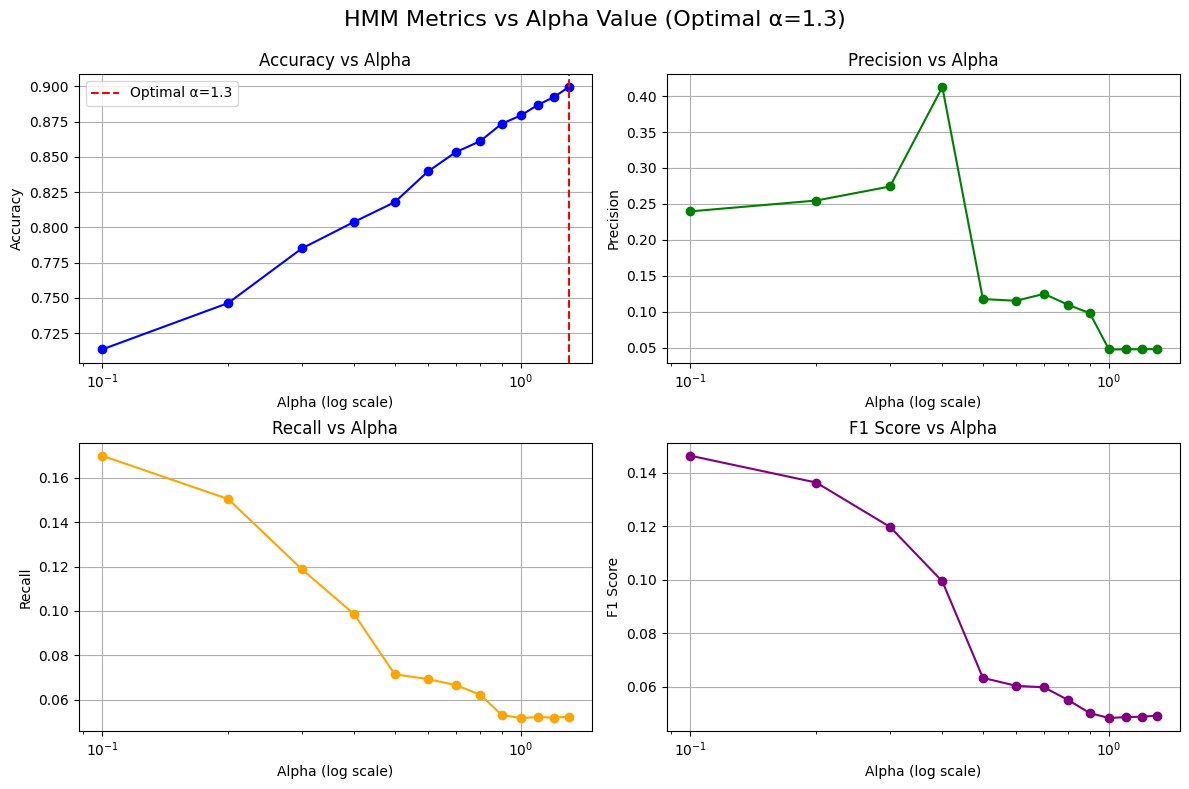

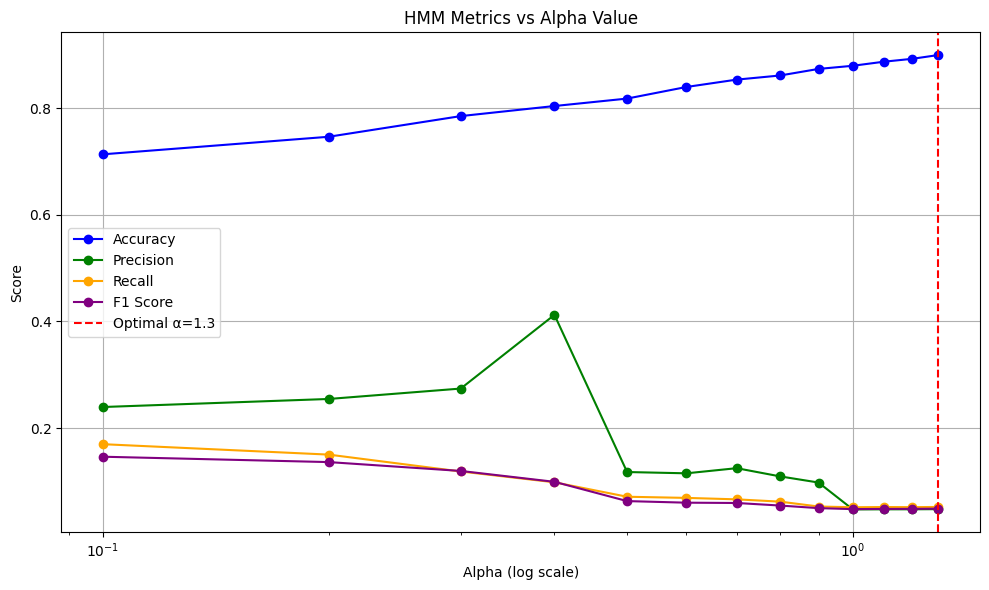

In [30]:
train_sentences = load_data('train.txt')
dev_sentences = load_data('dev.txt')

optimal_alpha, best_metrics, results = find_optimal_alpha(
    train_data=train_sentences,
    dev_data=dev_sentences,
    alpha_values=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.1, 1.2, 1.3],
    n_gram=2,
    use_context=False
)


alphas = list(results.keys())
accuracies = [results[alpha]['accuracy'] for alpha in alphas]
precisions = [results[alpha]['precision'] for alpha in alphas]
recalls = [results[alpha]['recall'] for alpha in alphas]
f1_scores = [results[alpha]['f1'] for alpha in alphas]

plt.figure(figsize=(12, 8))

# Create subplots for each metric
plt.subplot(2, 2, 1)
plt.plot(alphas, accuracies, 'o-', color='blue')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Alpha')
plt.grid(True)
plt.axvline(x=optimal_alpha, color='r', linestyle='--', label=f'Optimal α={optimal_alpha}')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(alphas, precisions, 'o-', color='green')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Precision')
plt.title('Precision vs Alpha')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(alphas, recalls, 'o-', color='orange')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Recall')
plt.title('Recall vs Alpha')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(alphas, f1_scores, 'o-', color='purple')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Alpha')
plt.grid(True)

plt.tight_layout()
plt.suptitle(f'HMM Metrics vs Alpha Value (Optimal α={optimal_alpha})', fontsize=16)
plt.subplots_adjust(top=0.9)
plt.show()

# Optional: Combined plot with all metrics
plt.figure(figsize=(10, 6))
plt.plot(alphas, accuracies, 'o-', label='Accuracy', color='blue')
plt.plot(alphas, precisions, 'o-', label='Precision', color='green')
plt.plot(alphas, recalls, 'o-', label='Recall', color='orange')
plt.plot(alphas, f1_scores, 'o-', label='F1 Score', color='purple')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Score')
plt.title('HMM Metrics vs Alpha Value')
plt.grid(True)
plt.axvline(x=optimal_alpha, color='r', linestyle='--', label=f'Optimal α={optimal_alpha}')
plt.legend()
plt.tight_layout()
plt.show()


Helper functions to plot distribution of tags and entities among the entire dataset

In [31]:
def plot_tag_distribution(file_path):
    """
    Plot the distribution of named entity tags from a file.

    Args:
        file_path: Path to the data file
    """
    # Load data
    sentences = load_data(file_path)

    # Extract tags
    all_tags = [tag for sentence in sentences for _, tag in sentence]

    # Count tag distribution
    tag_counts = Counter(all_tags)

    # Convert to DataFrame for visualization
    tag_df = pd.DataFrame(tag_counts.items(), columns=['Tag', 'Count']).sort_values(by='Count', ascending=False)

    # Create a bar plot
    plt.figure(figsize=(12, 6))
    plt.bar(tag_df['Tag'], tag_df['Count'])
    plt.title(f'Distribution of Named Entity Tags in {file_path}')
    plt.xlabel('Tags')
    plt.ylabel('Count')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.savefig(f'tag_distribution_bar_{file_path.split(".")[0]}.png')
    plt.show()

    # Create a pie chart for the top 10 tags (excluding 'O' if it dominates)
    if 'O' in tag_df['Tag'].values:
        # Create a copy without 'O' tag
        non_o_tags = tag_df[tag_df['Tag'] != 'O']
        top_tags = non_o_tags.head(10)
        plt.figure(figsize=(10, 10))
        plt.pie(top_tags['Count'], labels=top_tags['Tag'], autopct='%1.1f%%')
        plt.title(f'Top 10 Named Entity Tags Distribution (excluding O) in {file_path}')
        plt.axis('equal')
        plt.savefig(f'tag_distribution_pie_no_O_{file_path.split(".")[0]}.png')
        plt.show()

    # Also show a pie with O included
    top_10_tags = tag_df.head(10)
    plt.figure(figsize=(10, 10))
    plt.pie(top_10_tags['Count'], labels=top_10_tags['Tag'], autopct='%1.1f%%')
    plt.title(f'Top 10 Named Entity Tags Distribution in {file_path}')
    plt.axis('equal')
    plt.savefig(f'tag_distribution_pie_{file_path.split(".")[0]}.png')
    plt.show()

    # Return the tag distribution dataframe for further analysis
    return tag_df

def plot_sentence_length_distribution(file_path):
    """
    Plot the distribution of sentence lengths from a file.

    Args:
        file_path: Path to the data file
    """
    # Load data
    sentences = load_data(file_path)

    # Calculate sentence lengths
    sentence_lengths = [len(sentence) for sentence in sentences]

    # Plot histogram
    plt.figure(figsize=(10, 6))
    plt.hist(sentence_lengths, bins=30, alpha=0.7)
    plt.title(f'Sentence Length Distribution in {file_path}')
    plt.xlabel('Sentence Length (tokens)')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    plt.savefig(f'sentence_length_distribution_{file_path.split(".")[0]}.png')
    plt.show()

    # Print some statistics
    print(f"Sentence length statistics for {file_path}:")
    print(f"Min length: {min(sentence_lengths)}")
    print(f"Max length: {max(sentence_lengths)}")
    print(f"Average length: {sum(sentence_lengths)/len(sentence_lengths):.2f}")

    return sentence_lengths

def plot_entity_length_distribution(file_path):
    """
    Plot the distribution of entity lengths from a file.

    Args:
        file_path: Path to the data file
    """
    # Load data
    sentences = load_data(file_path)

    # Extract entity lengths
    entity_lengths = []
    current_entity_length = 0

    for sentence in sentences:
        for _, tag in sentence:
            if tag.startswith('B-'):
                if current_entity_length > 0:
                    entity_lengths.append(current_entity_length)
                current_entity_length = 1
            elif tag.startswith('I-'):
                current_entity_length += 1
            else:  # 'O' tag
                if current_entity_length > 0:
                    entity_lengths.append(current_entity_length)
                    current_entity_length = 0
        # Handle entity at end of sentence
        if current_entity_length > 0:
            entity_lengths.append(current_entity_length)
            current_entity_length = 0

    # Plot histogram
    plt.figure(figsize=(10, 6))
    plt.hist(entity_lengths, bins=range(1, max(entity_lengths) + 2), alpha=0.7)
    plt.title(f'Entity Length Distribution in {file_path}')
    plt.xlabel('Entity Length (tokens)')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    plt.savefig(f'entity_length_distribution_{file_path.split(".")[0]}.png')
    plt.show()

    # Print some statistics
    print(f"Entity length statistics for {file_path}:")
    print(f"Min length: {min(entity_lengths)}")
    print(f"Max length: {max(entity_lengths)}")
    print(f"Average length: {sum(entity_lengths)/len(entity_lengths):.2f}")
    print(f"Total entities: {len(entity_lengths)}")

    return entity_lengths

def compare_tag_distributions(file_paths):
    """
    Compare tag distributions across multiple files.

    Args:
        file_paths: List of paths to data files
    """
    # Get tag distributions for each file
    tag_dfs = {}
    for file_path in file_paths:
        tag_dfs[file_path] = plot_tag_distribution(file_path)

    # Plot comparison bar chart for top 10 tags (excluding 'O')
    plt.figure(figsize=(14, 8))

    # Get all unique tags across files (excluding 'O')
    all_tags = set()
    for df in tag_dfs.values():
        all_tags.update(df[df['Tag'] != 'O']['Tag'].values)

    # Prepare data for plotting
    tag_list = sorted(list(all_tags))
    file_names = [path.split(".")[0] for path in file_paths]

    # Create grouped bar chart
    bar_width = 0.8 / len(file_paths)
    for i, (file_path, df) in enumerate(tag_dfs.items()):
        # Convert to dictionary for easy lookup
        tag_dict = df.set_index('Tag')['Count'].to_dict()

        # Get counts for each tag (0 if tag not present)
        counts = [tag_dict.get(tag, 0) for tag in tag_list]

        # Plot bars
        positions = [j + (i * bar_width) for j in range(len(tag_list))]
        plt.bar(positions, counts, width=bar_width, label=file_path.split(".")[0])

    # Set chart properties
    plt.title('Comparison of Tag Distributions (excluding O)')
    plt.xlabel('Tags')
    plt.ylabel('Count')
    plt.xticks([i + (bar_width * (len(file_paths) - 1) / 2) for i in range(len(tag_list))], tag_list, rotation=90)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'tag_distribution_comparison.png')
    plt.show()


Helper function to plot metrics of model configuration results overall and class-wise both

In [32]:
def plot_model_metrics(results):
    """
    Plot F1 score, precision, accuracy, and recall metrics for all models.

    Args:
        results: Dictionary with model names as keys and metrics as values
    """
    # Extract model names and metrics
    model_names = list(results.keys())

    # Extract metrics for test set
    accuracies = [results[model]['test']['accuracy'] for model in model_names]
    precisions = [results[model]['test']['macro_precision'] for model in model_names]
    recalls = [results[model]['test']['macro_recall'] for model in model_names]
    f1_scores = [results[model]['test']['macro_f1'] for model in model_names]

    # Set up plot
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Model Performance Metrics Comparison', fontsize=16)

    # Bar positions
    x = np.arange(len(model_names))
    width = 0.7

    # Plot accuracy
    axes[0, 0].bar(x, accuracies, width, color='skyblue')
    axes[0, 0].set_title('Accuracy')
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(model_names, rotation=45, ha='right')
    axes[0, 0].set_ylim(0, 1)
    for i, v in enumerate(accuracies):
        axes[0, 0].text(i, v + 0.01, f'{v:.4f}', ha='center')

    # Plot precision
    axes[0, 1].bar(x, precisions, width, color='lightgreen')
    axes[0, 1].set_title('Precision')
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(model_names, rotation=45, ha='right')
    axes[0, 1].set_ylim(0, 1)
    for i, v in enumerate(precisions):
        axes[0, 1].text(i, v + 0.01, f'{v:.4f}', ha='center')

    # Plot recall
    axes[1, 0].bar(x, recalls, width, color='salmon')
    axes[1, 0].set_title('Recall')
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(model_names, rotation=45, ha='right')
    axes[1, 0].set_ylim(0, 1)
    for i, v in enumerate(recalls):
        axes[1, 0].text(i, v + 0.01, f'{v:.4f}', ha='center')

    # Plot F1 score
    axes[1, 1].bar(x, f1_scores, width, color='plum')
    axes[1, 1].set_title('F1 Score')
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(model_names, rotation=45, ha='right')
    axes[1, 1].set_ylim(0, 1)
    for i, v in enumerate(f1_scores):
        axes[1, 1].text(i, v + 0.01, f'{v:.4f}', ha='center')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.savefig('model_metrics_comparison.png')
    plt.show()

    # Create a line plot comparing all metrics across models
    plt.figure(figsize=(12, 6))

    # Plot lines for each metric
    plt.plot(model_names, accuracies, 'o-', label='Accuracy', linewidth=2)
    plt.plot(model_names, precisions, 's-', label='Precision', linewidth=2)
    plt.plot(model_names, recalls, '^-', label='Recall', linewidth=2)
    plt.plot(model_names, f1_scores, 'd-', label='F1 Score', linewidth=2)

    plt.title('Comparison of Metrics Across Models')
    plt.xlabel('Model')
    plt.ylabel('Score')
    plt.ylim(0, 1)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('metrics_line_comparison.png')
    plt.show()

    # Create a radar chart for comparing models
    fig = plt.figure(figsize=(10, 10))

    # Number of variables
    categories = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
    N = len(categories)

    # What will be the angle of each axis in the plot
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]  # Close the loop

    # Initialize the subplot
    ax = plt.subplot(111, polar=True)

    # Draw one axis per variable and add labels
    plt.xticks(angles[:-1], categories)

    # Draw the y-axis labels (0-1)
    ax.set_rlabel_position(0)
    plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=8)
    plt.ylim(0, 1)

    # Plot each model
    for i, model in enumerate(model_names):
        values = [
            results[model]['test']['accuracy'],
            results[model]['test']['macro_precision'],
            results[model]['test']['macro_recall'],
            results[model]['test']['macro_f1']
        ]
        values += values[:1]  # Close the loop

        # Plot values
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=model)
        ax.fill(angles, values, alpha=0.1)

    # Add legend
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.title('Model Performance Comparison (Radar Chart)')
    plt.tight_layout()
    plt.savefig('model_radar_comparison.png')
    plt.show()

def plot_class_metrics(results, model_name, dataset='test'):
    """
    Plot metrics for each class for a specific model.

    Args:
        results: Dictionary with model metrics
        model_name: Name of the model to plot
        dataset: 'test' or 'valid'
    """
    # Extract class metrics
    class_metrics = results[model_name][dataset]['tag_metrics']

    # Get classes (excluding 'O' as it dominates)
    classes = [cls for cls in class_metrics.keys() if cls != 'O']

    # Extract metrics for each class
    precisions = [class_metrics[cls]['precision'] for cls in classes]
    recalls = [class_metrics[cls]['recall'] for cls in classes]
    f1_scores = [class_metrics[cls]['f1'] for cls in classes]

    # Set up plot
    fig, axes = plt.subplots(3, 1, figsize=(14, 18))
    fig.suptitle(f'Class Metrics for {model_name} ({dataset} set)', fontsize=16)

    # Bar positions
    x = np.arange(len(classes))
    width = 0.7

    # Plot precision
    axes[0].bar(x, precisions, width, color='lightgreen')
    axes[0].set_title('Precision by Class')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(classes, rotation=90)
    axes[0].set_ylim(0, 1)

    # Plot recall
    axes[1].bar(x, recalls, width, color='salmon')
    axes[1].set_title('Recall by Class')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(classes, rotation=90)
    axes[1].set_ylim(0, 1)

    # Plot F1 score
    axes[2].bar(x, f1_scores, width, color='plum')
    axes[2].set_title('F1 Score by Class')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(classes, rotation=90)
    axes[2].set_ylim(0, 1)

    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.savefig(f'class_metrics_{model_name}_{dataset}.png')
    plt.show()


main() function to call all above defined functions over all 4 required configuration of models, Bigram without and with context and Trigram with and without context

In [33]:
def main():
    # Load data
    train_file = 'train.txt'
    valid_file = 'dev.txt'
    test_file = 'test.txt'

    train_sentences = load_data('train.txt')
    valid_sentences = load_data('dev.txt')
    test_sentences = load_data('test.txt')

    # Extract features
    train_words, train_tags = extract_features(train_sentences)
    valid_words, valid_tags = extract_features(valid_sentences)
    test_words, test_tags = extract_features(test_sentences)

    # Plot tag distributions
    print("Plotting tag distribution for training data...")
    plot_tag_distribution(train_file)

    print("Plotting sentence length distribution for training data...")
    plot_sentence_length_distribution(train_file)

    print("Plotting entity length distribution for training data...")
    plot_entity_length_distribution(train_file)

    print("Comparing tag distributions across datasets...")
    compare_tag_distributions([train_file, valid_file, test_file])


    # Define models to evaluate
    models = [
        {'n_gram': 2, 'use_context': False, 'name': 'Bigram without context'},
        {'n_gram': 3, 'use_context': False, 'name': 'Trigram without context'},
        {'n_gram': 2, 'use_context': True, 'name': 'Bigram with context'},
        {'n_gram': 3, 'use_context': True, 'name': 'Trigram with context'}
    ]

    results = {}

    for model_config in models:
        print(f"\nTraining {model_config['name']}...")

        # Initialize and train model
        model = HMM(n_gram=model_config['n_gram'], use_context=model_config['use_context'])
        model.train(train_sentences)

        # Make predictions
        valid_predictions = model.predict(valid_words)
        test_predictions = model.predict(test_words)

        # Evaluate on validation set
        valid_metrics = evaluate(valid_tags, valid_predictions)
        print(f"Validation metrics for {model_config['name']}:")
        print(f"Accuracy: {valid_metrics['accuracy']:.4f}")
        print(f"Precision: {valid_metrics['macro_precision']:.4f}")
        print(f"Recall: {valid_metrics['macro_recall']:.4f}")
        print(f"F1 Score: {valid_metrics['macro_f1']:.4f}")

        # Generate and print classification report for validation set
        print("\nValidation Classification Report:")
        y_true_valid = [tag for sent in valid_tags for tag in sent]
        y_pred_valid = [tag for sent in valid_predictions for tag in sent]
        print(classification_report(y_true_valid, y_pred_valid, zero_division=0))

        # Evaluate on test set
        test_metrics = evaluate(test_tags, test_predictions)
        print(f"Test metrics for {model_config['name']}:")
        print(f"Accuracy: {test_metrics['accuracy']:.4f}")
        print(f"Precision: {test_metrics['macro_precision']:.4f}")
        print(f"Recall: {test_metrics['macro_recall']:.4f}")
        print(f"F1 Score: {test_metrics['macro_f1']:.4f}")

        # Generate and print classification report for test set
        print("\nTest Classification Report:")
        y_true_test = [tag for sent in test_tags for tag in sent]
        y_pred_test = [tag for sent in test_predictions for tag in sent]
        print(classification_report(y_true_test, y_pred_test, zero_division=0))

        # Save predictions
        save_predictions(test_words, test_predictions, f"test_predictions_{model_config['n_gram']}gram_{'with' if model_config['use_context'] else 'without'}_context.txt")

        # Store results for comparison
        results[model_config['name']] = {
            'valid': valid_metrics,
            'test': test_metrics
        }

    # Compare results
    print("\n===== Model Comparison =====")
    print("\nTest Set Performance:")
    print("{:<25} {:<10} {:<10} {:<10} {:<10}".format("Model", "Accuracy", "Precision", "Recall", "F1 Score"))
    print("-" * 65)
    for model_name, metrics in results.items():
        test_metrics = metrics['test']
        print("{:<25} {:<10.4f} {:<10.4f} {:<10.4f} {:<10.4f}".format(
            model_name,
            test_metrics['accuracy'],
            test_metrics['macro_precision'],
            test_metrics['macro_recall'],
            test_metrics['macro_f1']
        ))

    print("\n===== Plotting Model Metrics =====")
    plot_model_metrics(results)

    # Plot class metrics for the best performing model
    best_model = max(results.keys(), key=lambda k: results[k]['test']['macro_f1'])
    print(f"\nPlotting class metrics for best model: {best_model}")
    plot_class_metrics(results, best_model, 'test')

calling the main( ) function itself


Plotting tag distribution for training data...


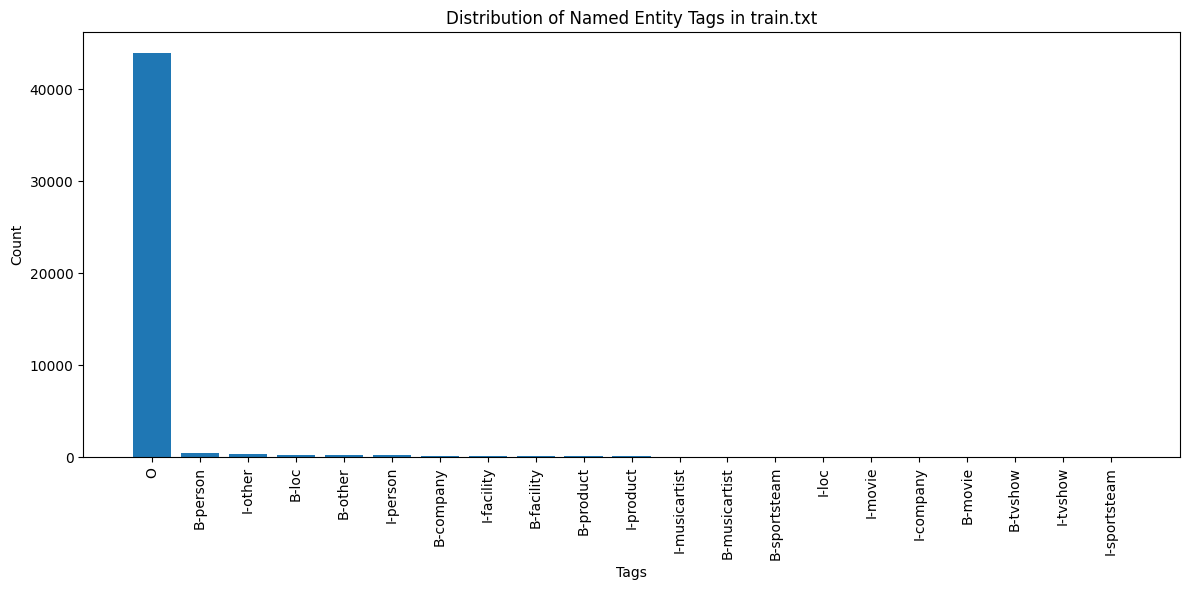

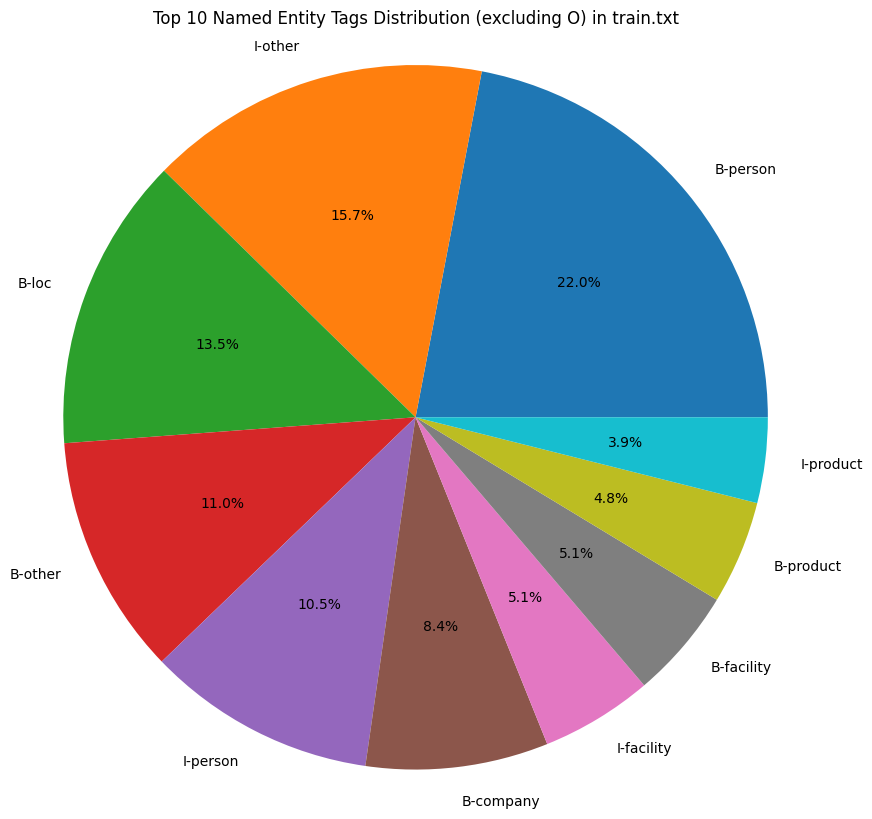

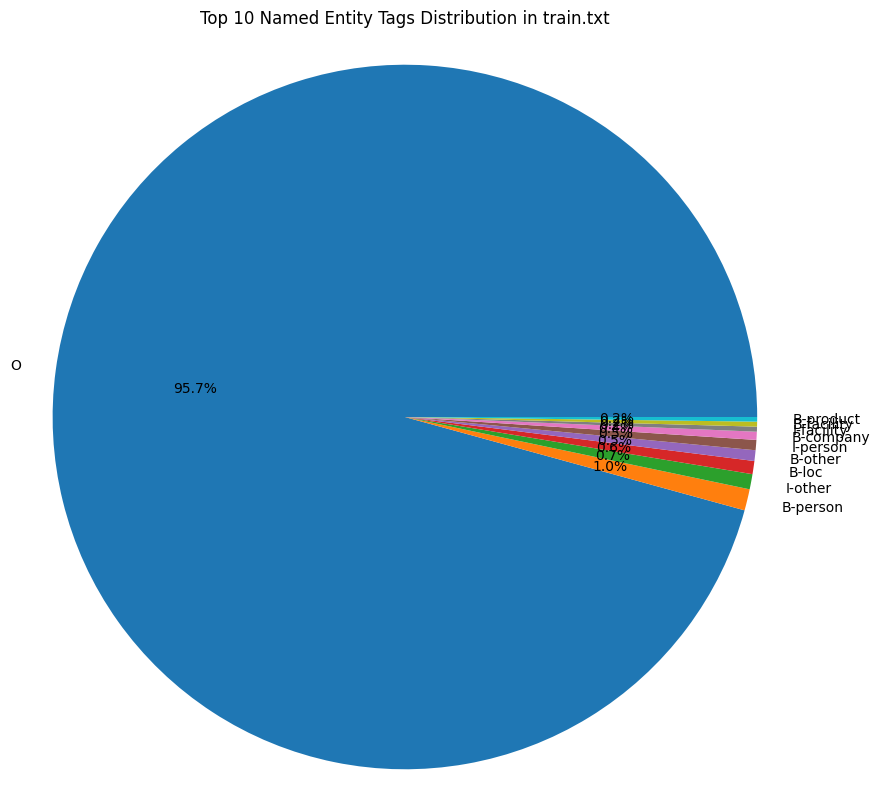

Plotting sentence length distribution for training data...


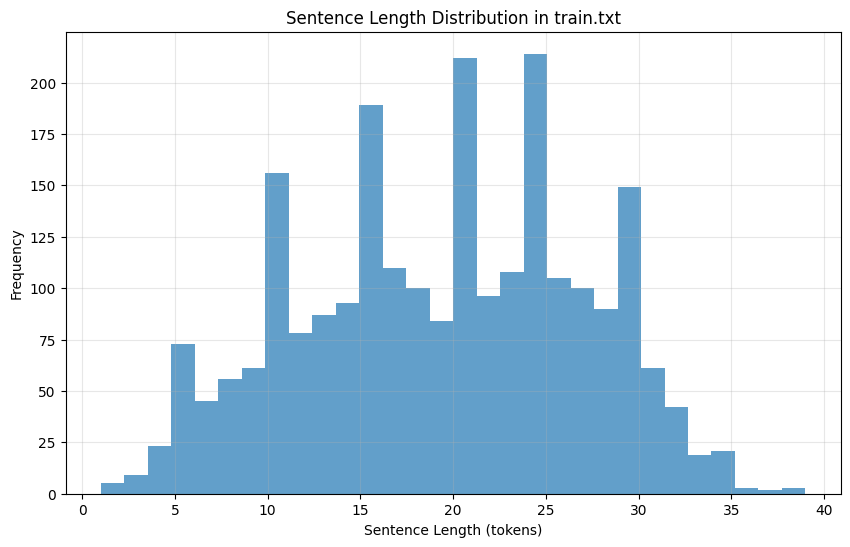

Sentence length statistics for train.txt:
Min length: 1
Max length: 39
Average length: 19.41
Plotting entity length distribution for training data...


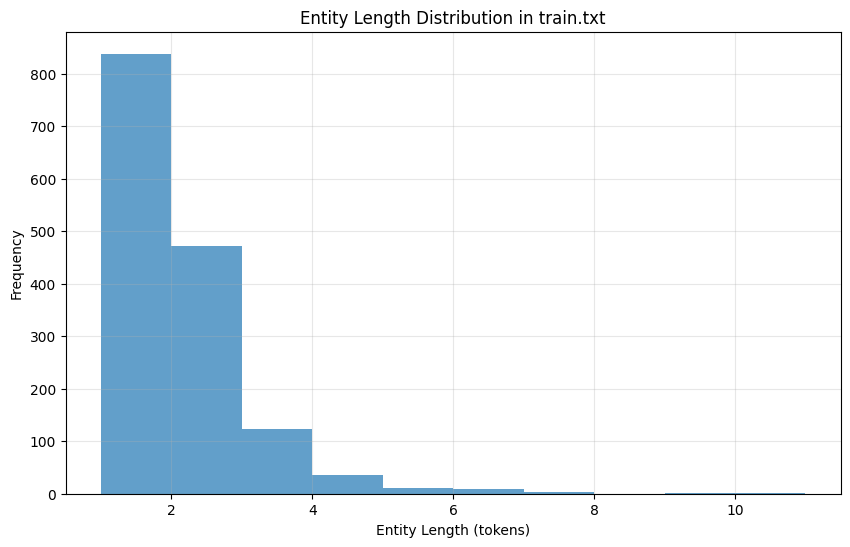

Entity length statistics for train.txt:
Min length: 1
Max length: 10
Average length: 1.65
Total entities: 1496
Comparing tag distributions across datasets...


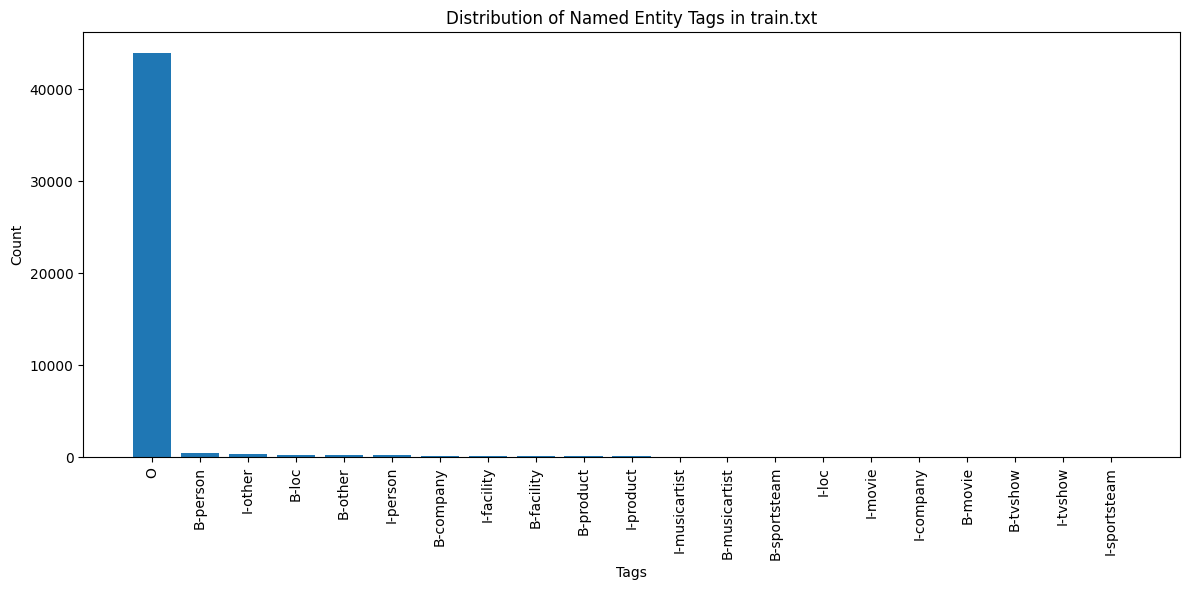

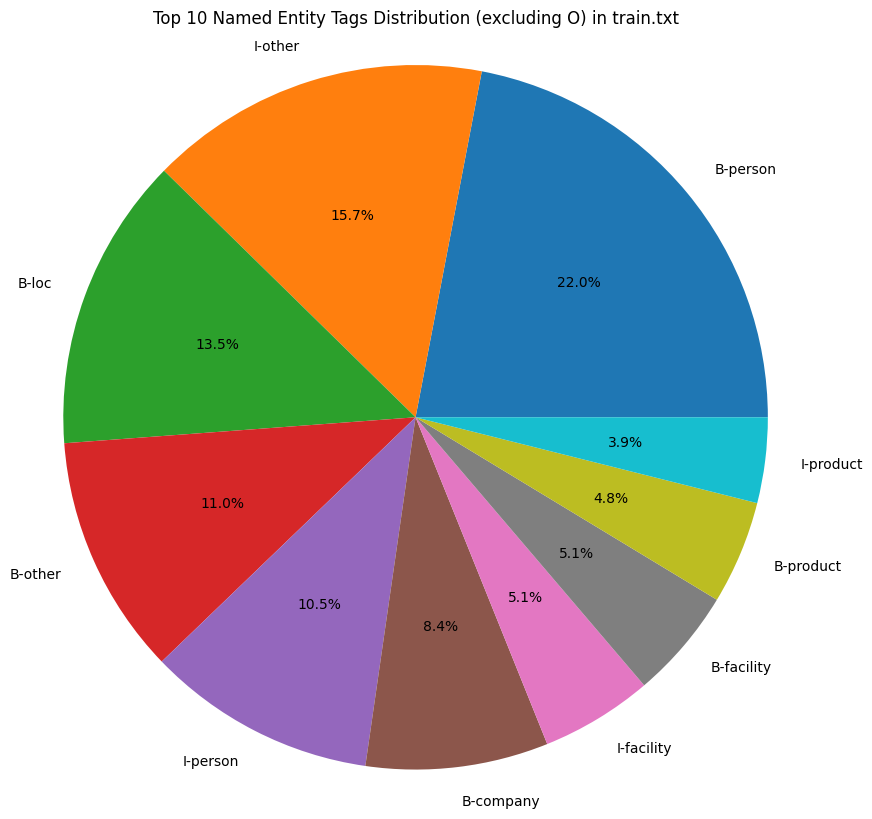

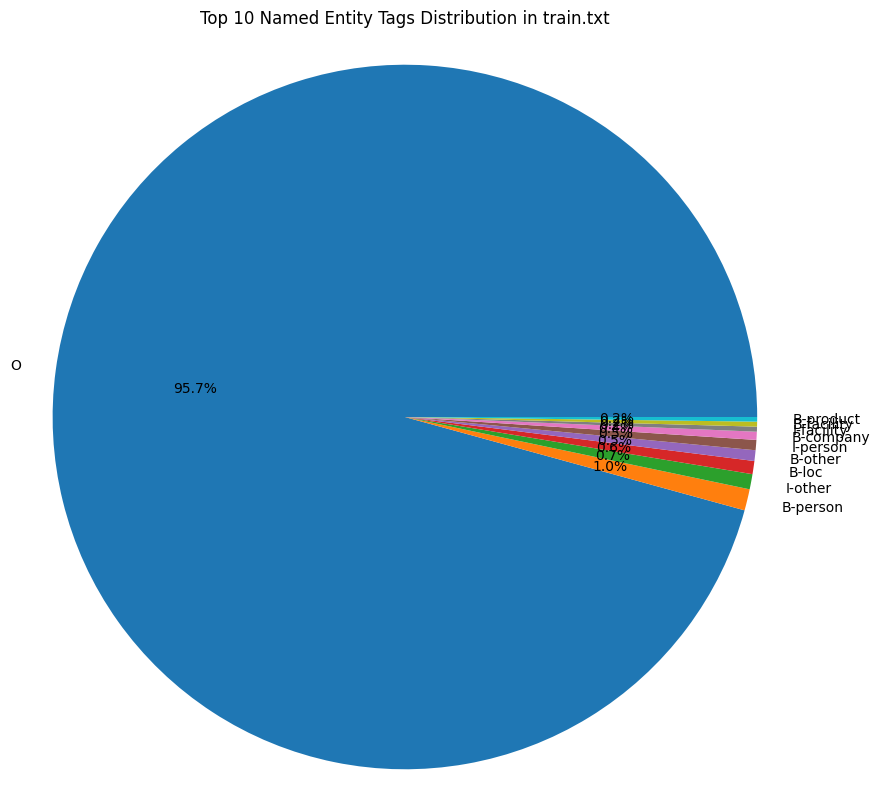

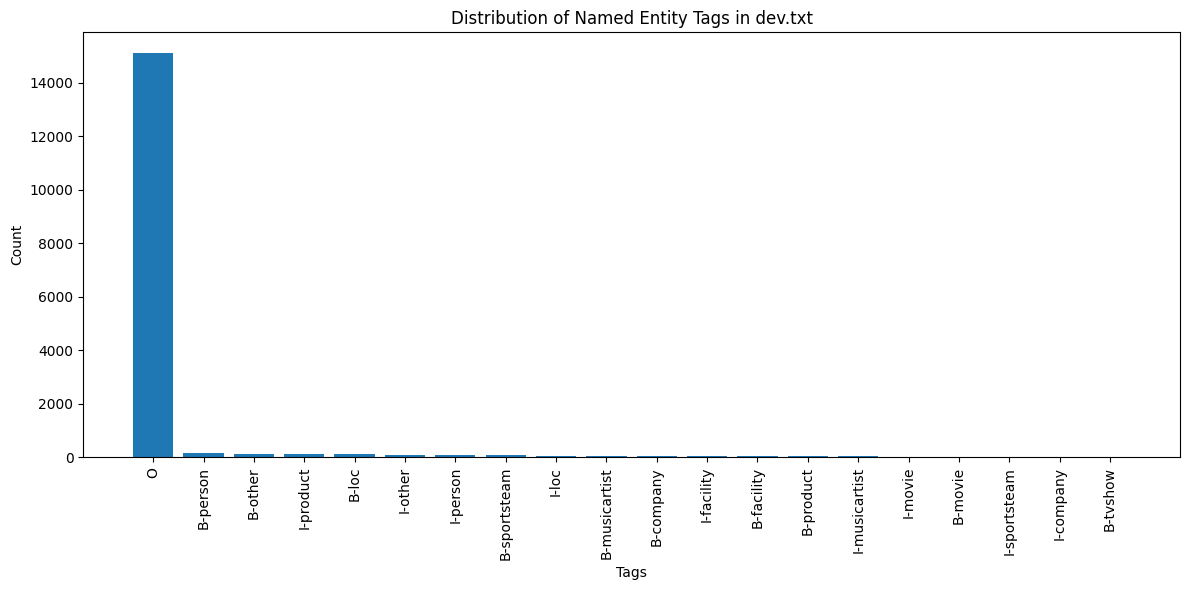

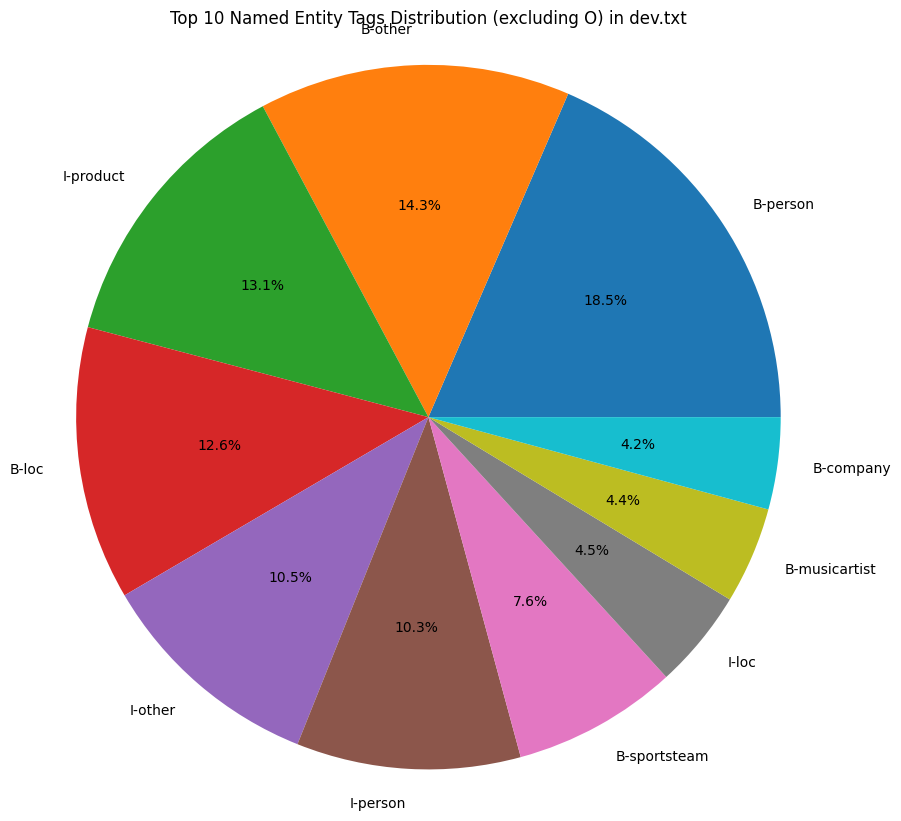

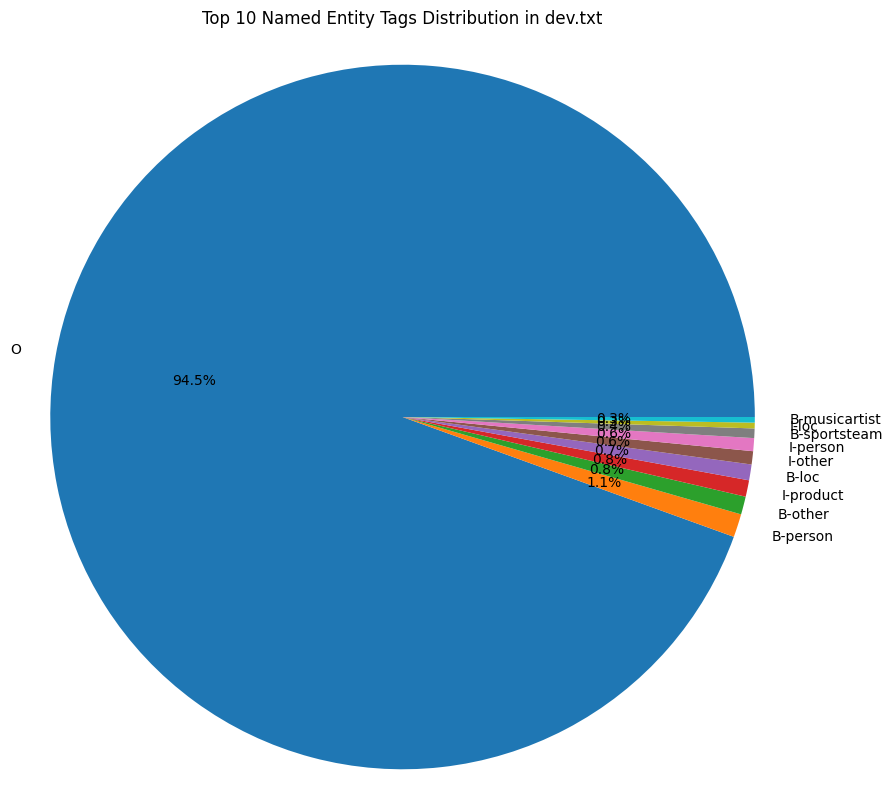

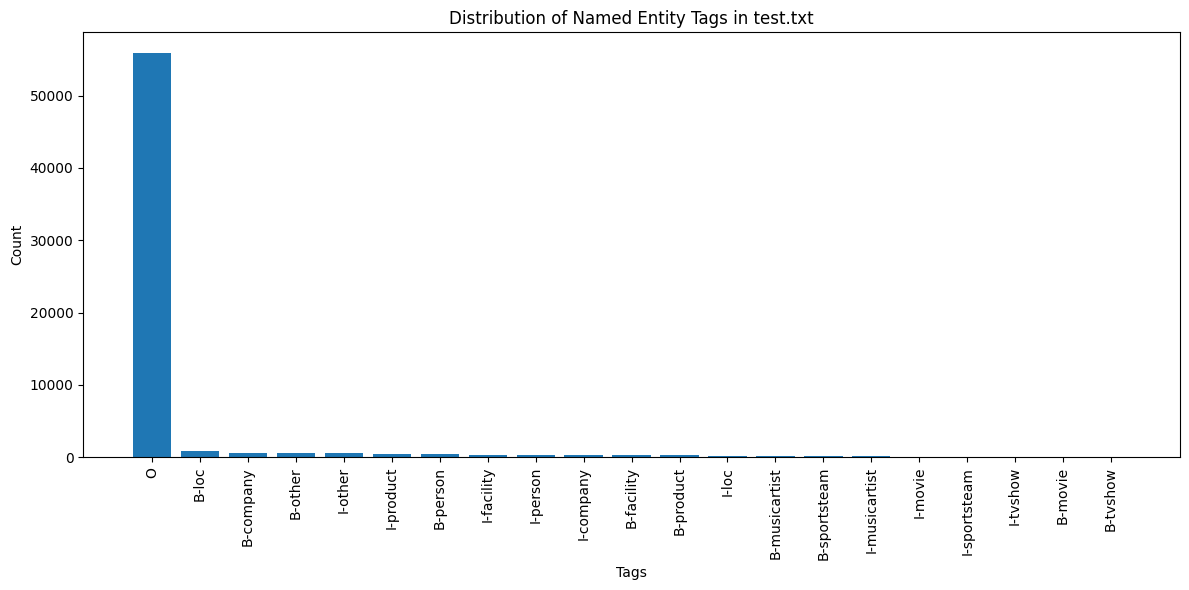

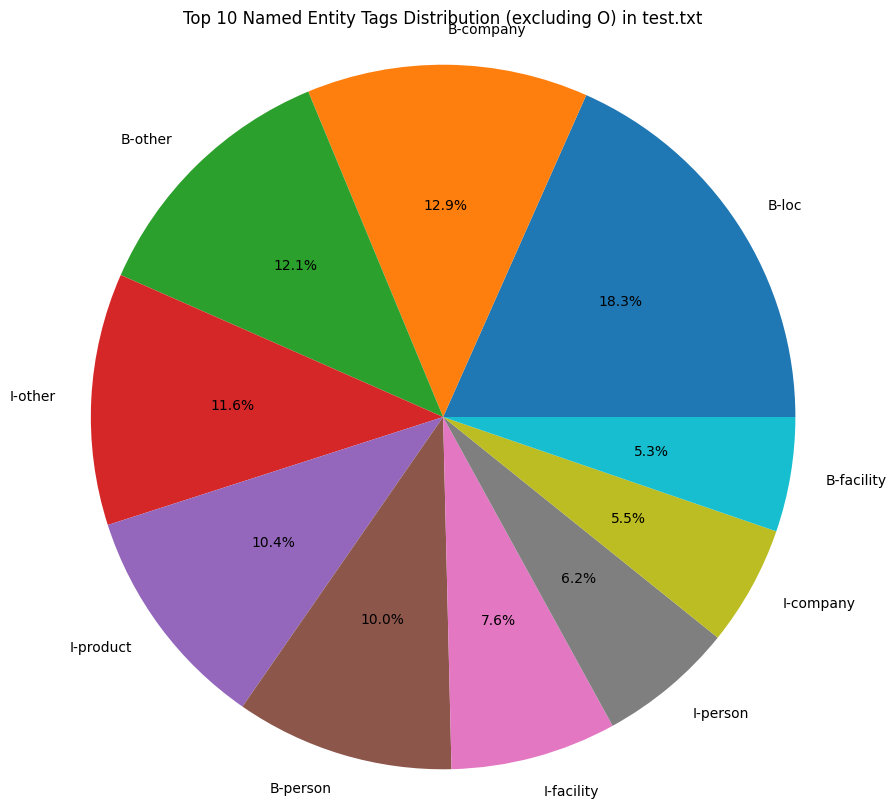

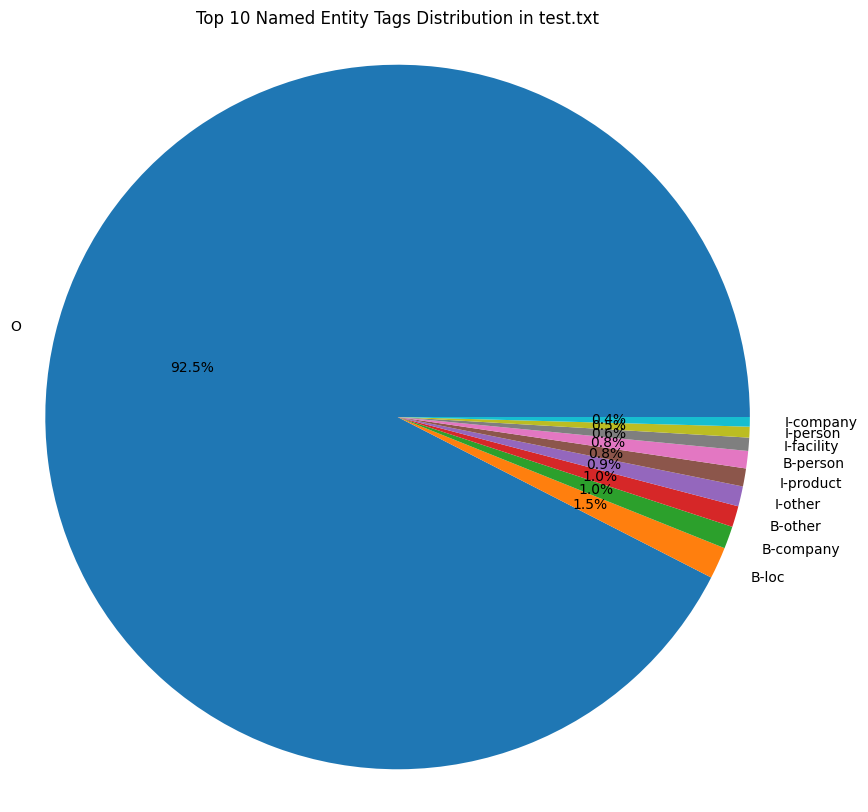

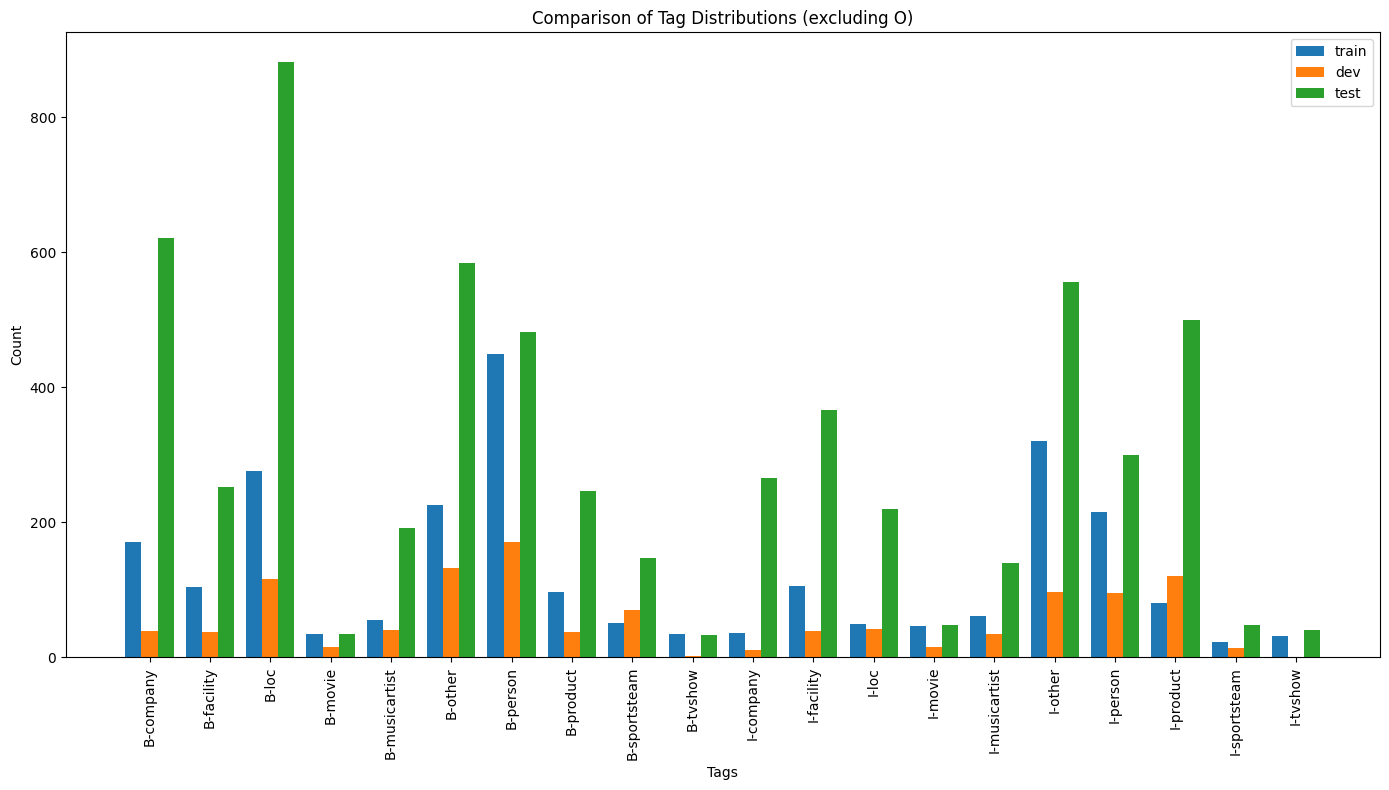


Training Bigram without context...
Validation metrics for Bigram without context:
Accuracy: 0.8039
Precision: 0.4124
Recall: 0.0985
F1 Score: 0.1590

Validation Classification Report:
               precision    recall  f1-score   support

    B-company       1.00      0.13      0.23        39
   B-facility       1.00      0.03      0.05        38
        B-loc       1.00      0.02      0.03       116
      B-movie       0.00      0.00      0.00        15
B-musicartist       0.00      0.00      0.00        41
      B-other       0.05      0.14      0.07       132
     B-person       0.65      0.10      0.17       171
    B-product       1.00      0.03      0.05        37
 B-sportsteam       0.00      0.00      0.00        70
     B-tvshow       0.00      0.00      0.00         2
    I-company       0.00      0.00      0.00        10
   I-facility       1.00      0.05      0.10        39
        I-loc       0.00      0.00      0.00        42
      I-movie       0.00      0.00      0.00

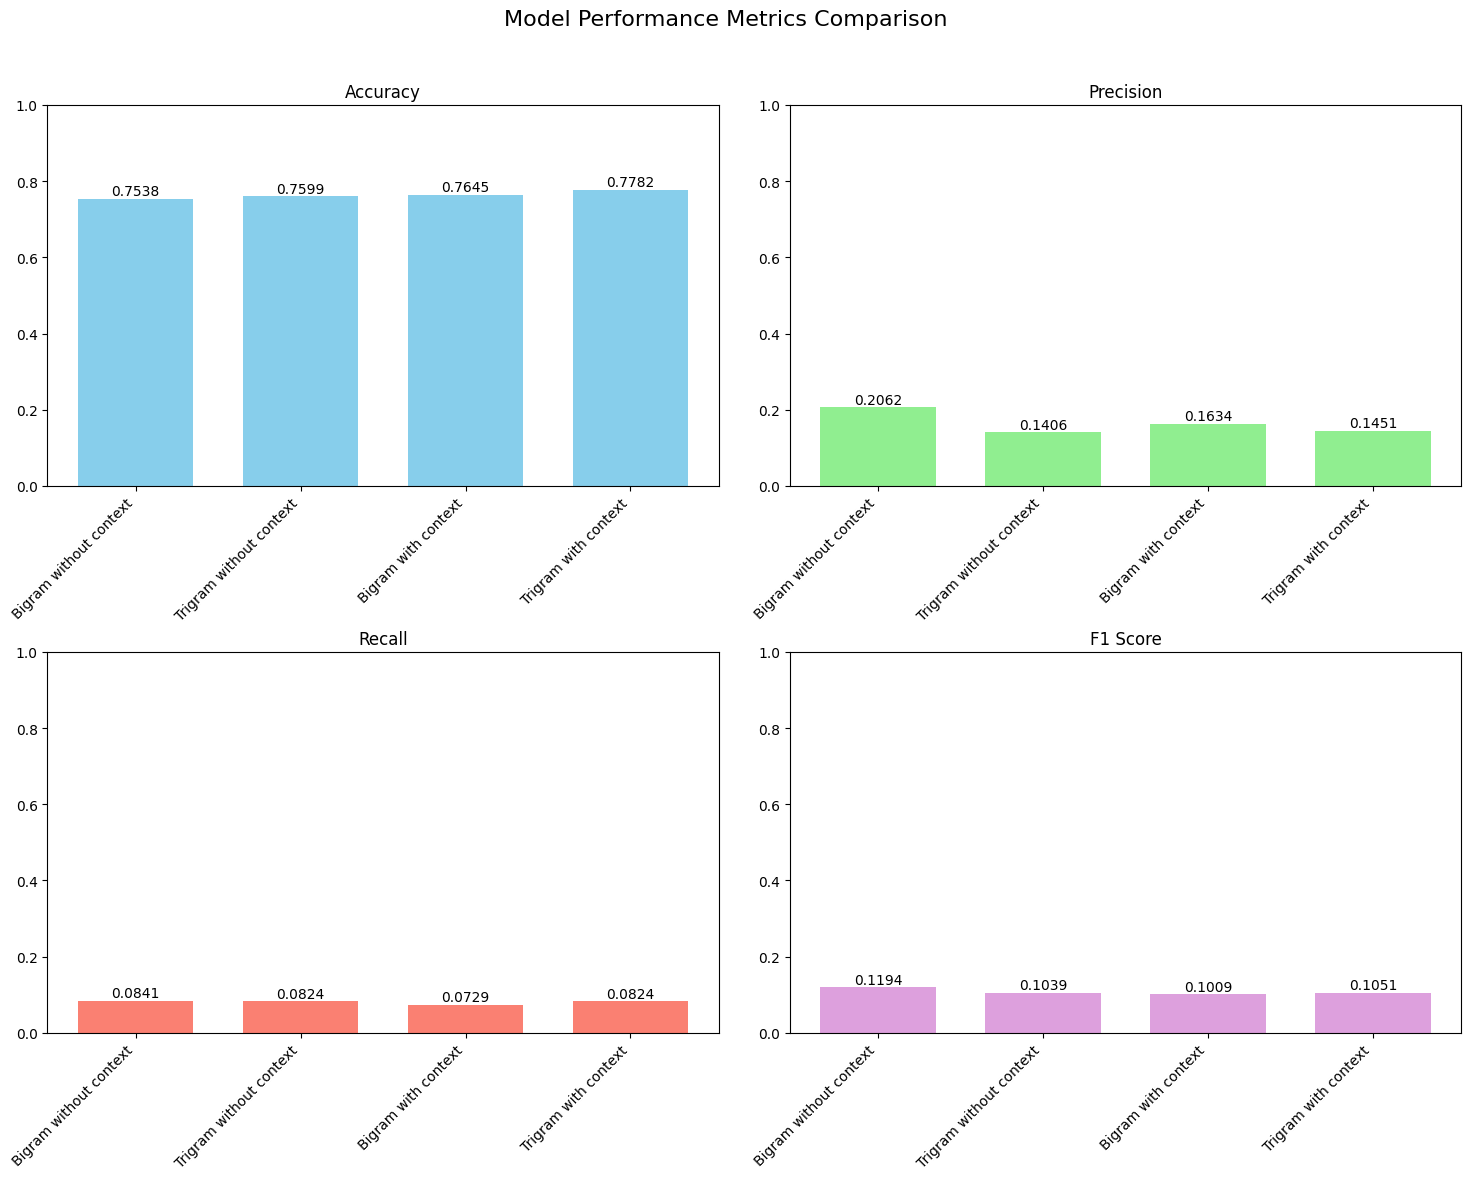

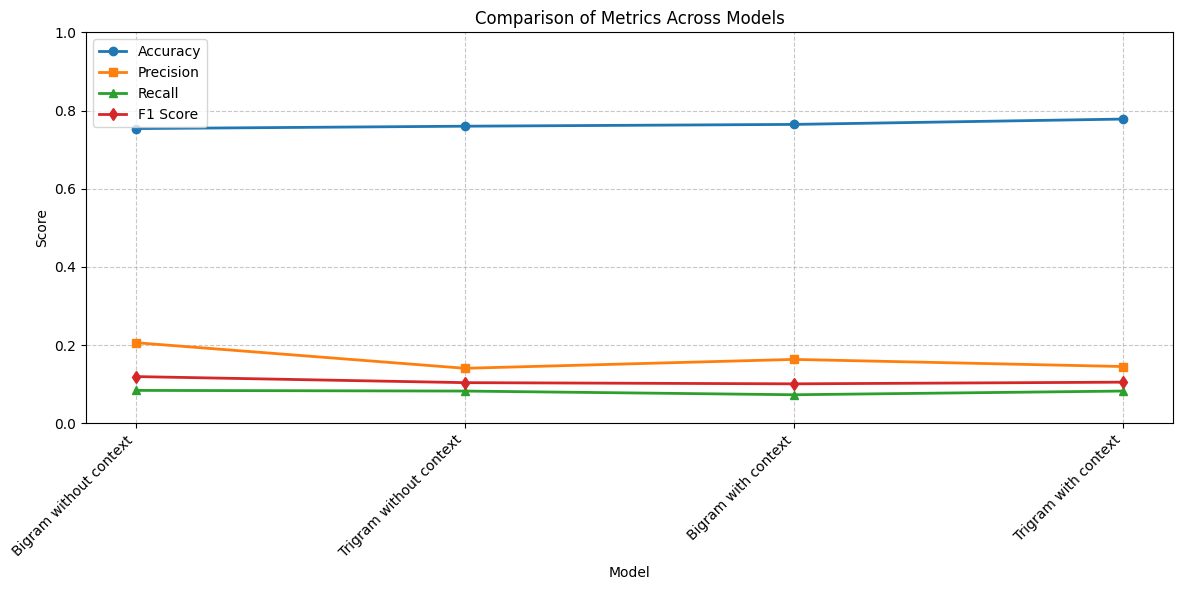

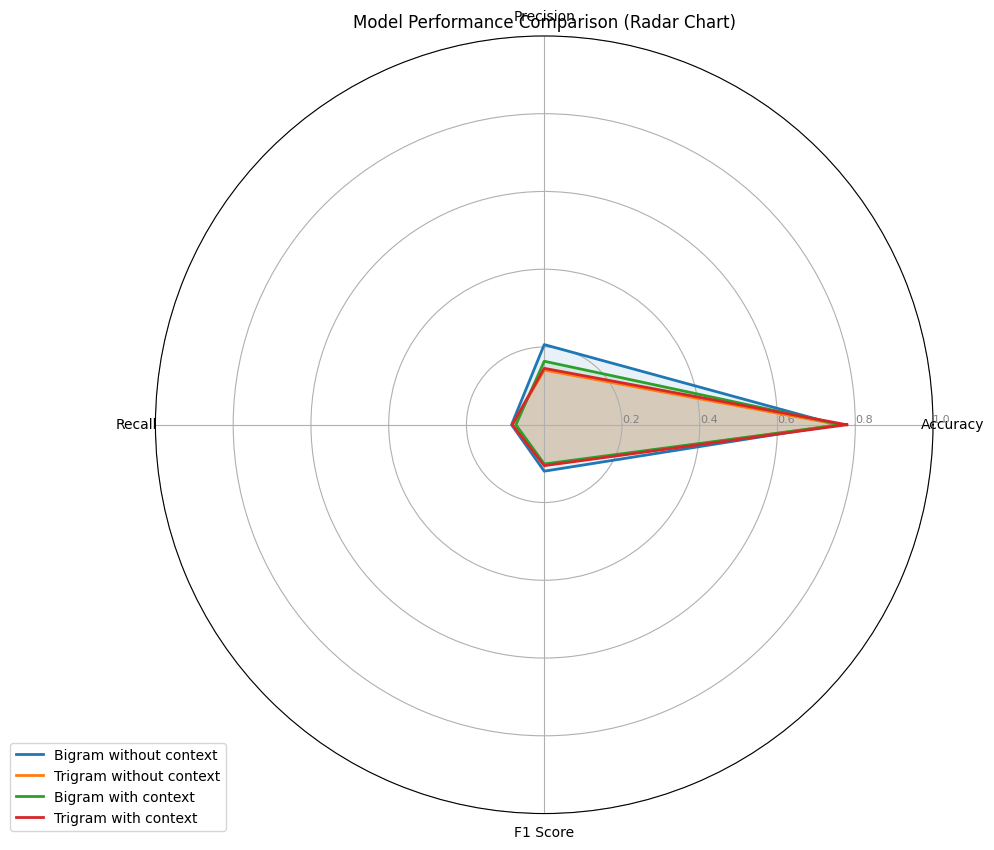


Plotting class metrics for best model: Bigram without context


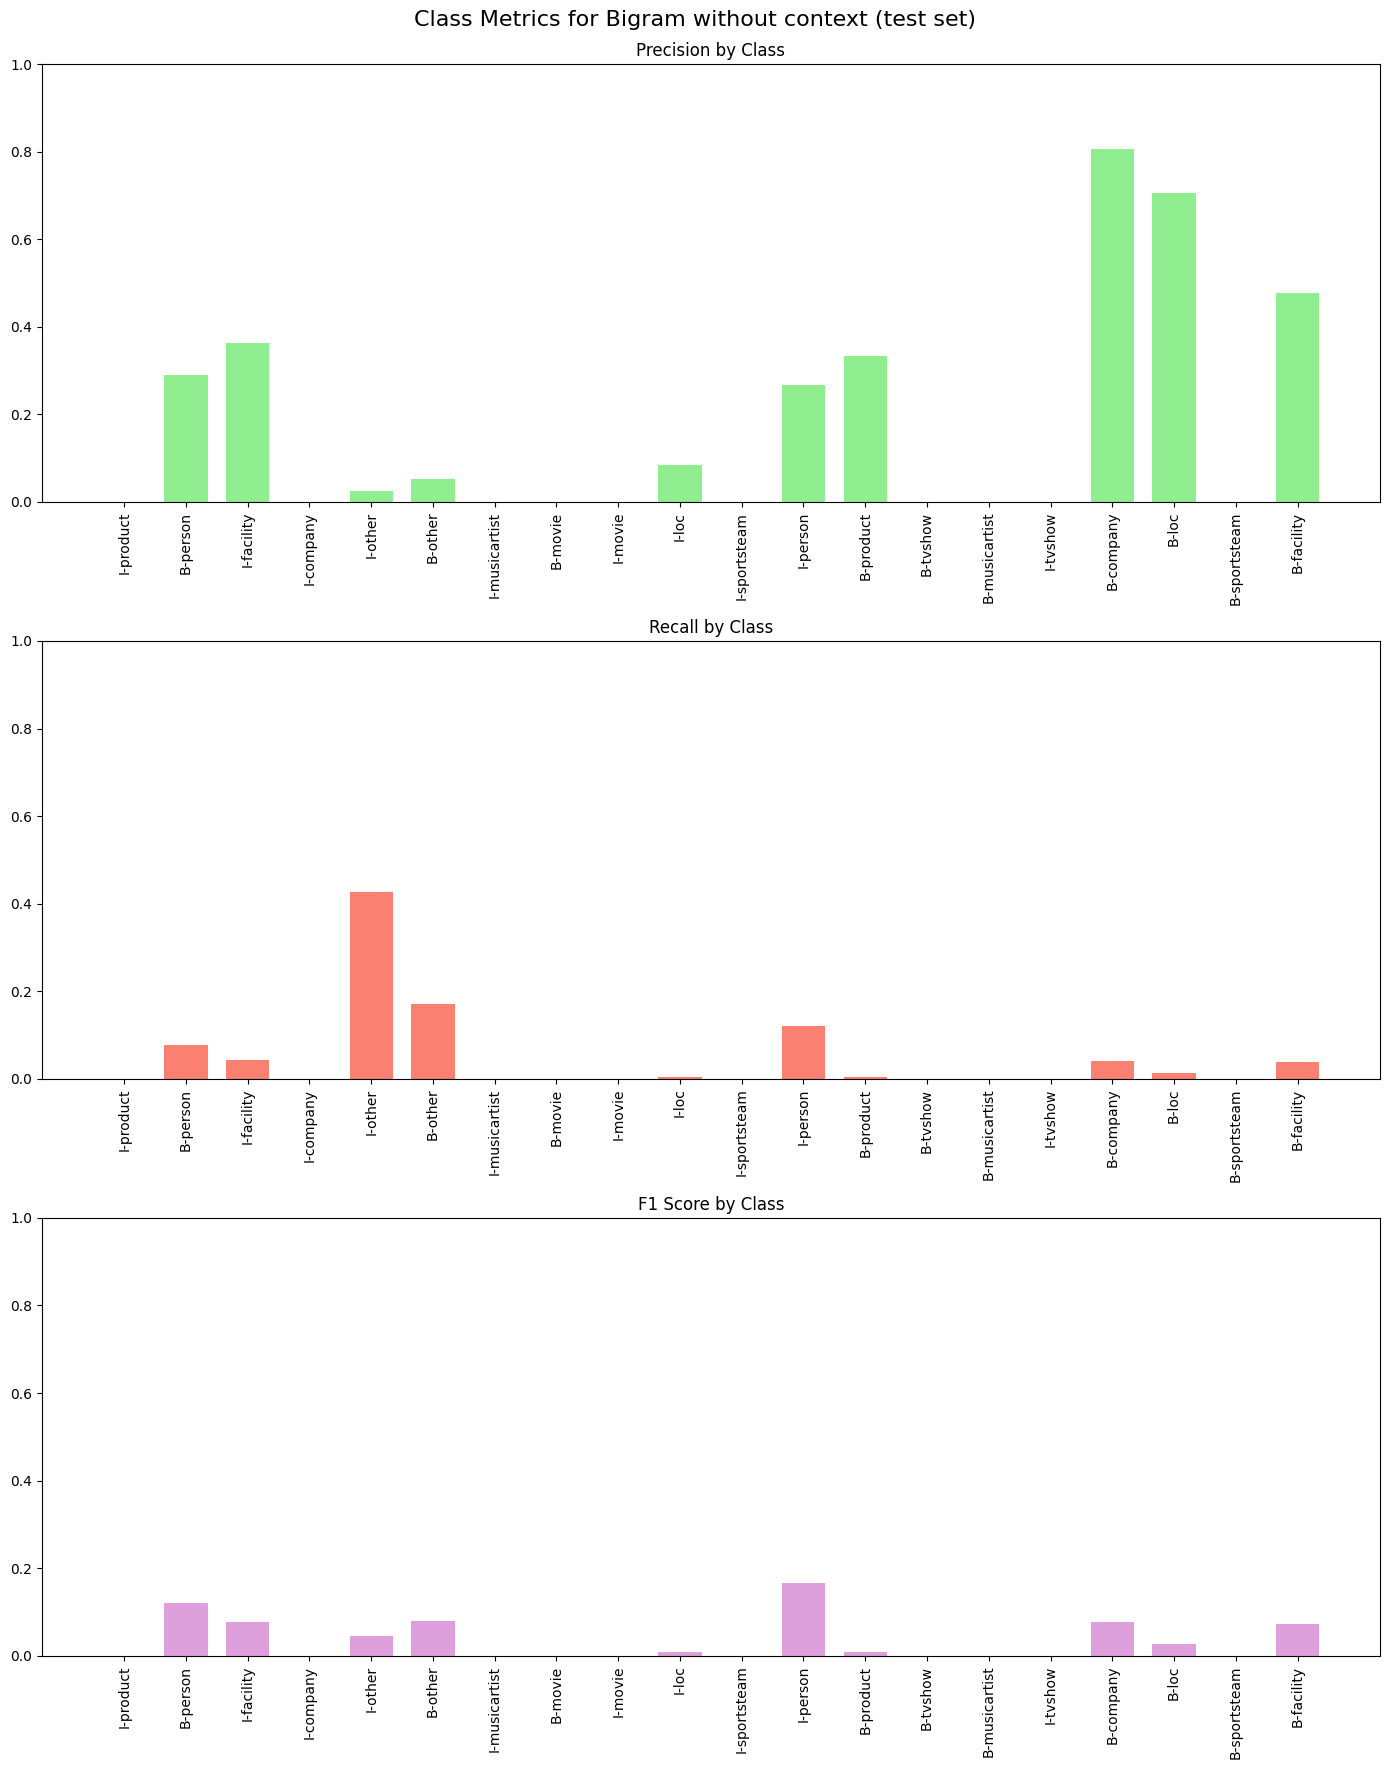

In [34]:
if __name__ == "__main__":
      main()